# CAP5636 — Project: Noise-Robust Food Image Classification
**Noise-Robust Fine-Grained Food Image Classification via Transfer Learning and Label-Smoothing Regularization**

Julian McKinley · Cristhian Cruz

---

## Learning Outcomes
By completing this notebook you will be able to:
- Understand why fine-grained food classification is hard (inter-class visual similarity + label noise)
- Apply **transfer learning** with two-phase fine-tuning (warm-up → top-block unfreeze)
- Implement and compare four noise-robust training strategies: standard CE, label smoothing, SCE, CutMix
- Quantitatively compare configurations using Top-1 / Top-5 accuracy
- Qualitatively interpret model decisions using **Grad-CAM** and confusion matrices

---
> ⚡ **FAST MODE is ON by default** — uses EfficientNet-B0, 10 classes, and a reduced sample count so the full notebook runs in ~15 minutes on a GPU.  
> Set `FAST_MODE = False` in Section 1 to replicate the full paper setup (EfficientNet-B4, 101 classes, 30 epochs).


## 1) Setup & Configuration

In [2]:
# ── 1a) Imports ──────────────────────────────────────────────────────────────
import os, json, time, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.models as tv_models
import torchvision.transforms as transforms
from torchvision.datasets import Food101
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
warnings.filterwarnings('ignore')
print("Imports OK")


/Users/julianmckinley/miniforge3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


In [3]:
# ── 1b) Configuration — edit here to switch fast ↔ full ─────────────────────
FAST_MODE = True          # True → quick demo  |  False → full paper setup

# Fast-mode settings (runs in ~15 min on GPU)
FAST_BACKBONE         = "efficientnet_b0"
FAST_CLASSES          = 10
FAST_TRAIN_PER_CLASS  = 200
FAST_VAL_PER_CLASS    = 50
FAST_WARMUP_EPOCHS    = 3
FAST_FINETUNE_EPOCHS  = 8

# Full settings (matches the project abstract)
FULL_BACKBONE         = "efficientnet_b4"
FULL_WARMUP_EPOCHS    = 5
FULL_FINETUNE_EPOCHS  = 30

# Shared
DATA_DIR      = "./data"
OUTPUT_DIR    = "./outputs"
BATCH_SIZE    = 32
LR            = 1e-4
WEIGHT_DECAY  = 1e-2
IMG_SIZE      = 224
UNFREEZE_BLOCKS = 3   # top EfficientNet blocks to unfreeze at fine-tune phase

os.makedirs(OUTPUT_DIR, exist_ok=True)

BACKBONE        = FAST_BACKBONE       if FAST_MODE else FULL_BACKBONE
WARMUP_EPOCHS   = FAST_WARMUP_EPOCHS  if FAST_MODE else FULL_WARMUP_EPOCHS
FINETUNE_EPOCHS = FAST_FINETUNE_EPOCHS if FAST_MODE else FULL_FINETUNE_EPOCHS

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"Mode          : {'FAST (subset, ' + str(FAST_CLASSES) + ' classes)' if FAST_MODE else 'FULL (101 classes)'}")
print(f"Backbone      : {BACKBONE}")
print(f"Warmup epochs : {WARMUP_EPOCHS}  |  Fine-tune epochs: {FINETUNE_EPOCHS}")


Device        : cpu
Mode          : FAST (subset, 10 classes)
Backbone      : efficientnet_b0
Warmup epochs : 3  |  Fine-tune epochs: 8


## 2) The Food-101 Dataset

**Food-101** (Bossard et al., ECCV 2014) contains 101,000 images across 101 food categories:

| Split | Images | Notes |
|---|---|---|
| Train | 75,750 | Collected automatically — **contains label noise** |
| Test | 25,250 | Manually verified — **clean** |

The intentional label noise in the training split is the central challenge this project addresses.
Fine-grained categories (e.g., *chocolate cake* vs *chocolate mousse*) differ only by subtle texture,
making noise-robust training especially important.

> **Dataset:** https://www.kaggle.com/datasets/kmader/food41  
> torchvision downloads it automatically on first run.


In [4]:
# ── 2a) Download & transforms ─────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print("Downloading Food-101 (first run only)...")
full_train_ds = Food101(root=DATA_DIR, split="train", transform=train_transform, download=True)
full_val_ds   = Food101(root=DATA_DIR, split="test",  transform=val_transform,   download=True)
ALL_CLASSES   = full_train_ds.classes
print(f"Full dataset: {len(full_train_ds):,} train  |  {len(full_val_ds):,} val  |  {len(ALL_CLASSES)} classes")


100%|██████████| 5.00G/5.00G [19:51<00:00, 4.20MB/s]  


Full dataset: 75,750 train  |  25,250 val  |  101 classes


In [5]:
# ── 2b) Class-balanced subsetting for FAST_MODE ──────────────────────────────
def make_subset(dataset, n_classes, n_per_class, seed=SEED):
    """Return a Subset with n_per_class images for the first n_classes classes."""
    rng = np.random.default_rng(seed)
    labels = np.array(dataset._labels)
    indices = []
    for cls_idx in range(n_classes):
        pool = np.where(labels == cls_idx)[0]
        chosen = rng.choice(pool, size=min(n_per_class, len(pool)), replace=False)
        indices.extend(chosen.tolist())
    return Subset(dataset, indices)

if FAST_MODE:
    train_ds    = make_subset(full_train_ds, FAST_CLASSES, FAST_TRAIN_PER_CLASS)
    val_ds      = make_subset(full_val_ds,   FAST_CLASSES, FAST_VAL_PER_CLASS)
    CLASS_NAMES = ALL_CLASSES[:FAST_CLASSES]
    N_CLASSES   = FAST_CLASSES
else:
    train_ds    = full_train_ds
    val_ds      = full_val_ds
    CLASS_NAMES = ALL_CLASSES
    N_CLASSES   = 101

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Active classes   : {N_CLASSES}")
print(f"Training samples : {len(train_ds):,}")
print(f"Validation samples: {len(val_ds):,}")


Active classes   : 10
Training samples : 2,000
Validation samples: 500


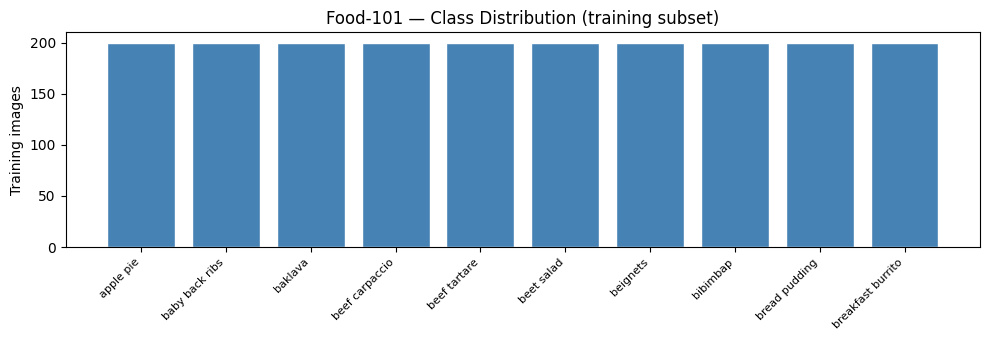

Min: 200  |  Max: 200  |  Mean: 200


In [6]:
# ── 2c) Class distribution ────────────────────────────────────────────────────
labels_arr = np.array(full_train_ds._labels[:len(train_ds) if not FAST_MODE else None])
if FAST_MODE:
    # labels from subset
    labels_arr = np.array([full_train_ds._labels[i] for i in train_ds.indices])

counts = np.bincount(labels_arr, minlength=N_CLASSES)[:N_CLASSES]
short_names = [c.replace("_", " ") for c in CLASS_NAMES]

plt.figure(figsize=(max(10, N_CLASSES * 0.5), 3.5))
plt.bar(short_names, counts, color="steelblue", edgecolor="white")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.ylabel("Training images"); plt.title("Food-101 — Class Distribution (training subset)")
plt.tight_layout(); plt.show()
print(f"Min: {counts.min()}  |  Max: {counts.max()}  |  Mean: {counts.mean():.0f}")


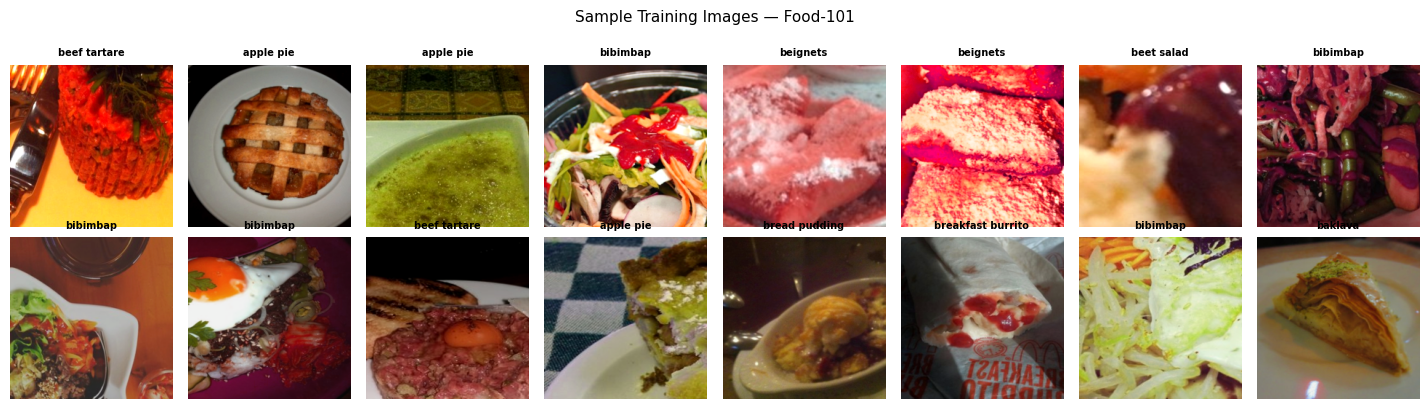

In [7]:
# ── 2d) Sample image grid ─────────────────────────────────────────────────────
INV_NORM = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

def show_grid(dataset, class_names, n_cols=8, n_rows=2, title=""):
    rng = np.random.default_rng(SEED)
    indices = rng.choice(len(dataset), n_cols * n_rows, replace=False)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.8, n_rows * 2))
    for ax, idx in zip(axes.flat, indices):
        img, label = dataset[int(idx)]
        ax.imshow(INV_NORM(img).permute(1,2,0).clamp(0,1).numpy())
        ax.set_title(class_names[label].replace("_"," "), fontsize=7, fontweight="bold")
        ax.axis("off")
    plt.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout(); plt.show()

show_grid(train_ds, CLASS_NAMES, title="Sample Training Images — Food-101")


## 3) Noise-Robust Loss Functions

Standard cross-entropy assigns probability 1.0 to whatever label the training image carries.
When labels are noisy, this forces the model to memorize wrong annotations.
We compare four strategies:

| # | Strategy | Key idea |
|---|---|---|
| CE | Standard cross-entropy | Baseline; overconfident on noisy labels |
| LS | Label smoothing (ε = 0.1) | Distributes 0.1 probability mass across all classes, preventing overconfidence |
| SCE | Symmetric Cross Entropy (Wang et al., 2019) | Adds a reverse-CE term that penalises confident wrong predictions |
| CM | CutMix (Yun et al., 2019) | Mixes image patches and labels from two samples; acts as a strong data augmentation and implicit regulariser |


In [8]:
# ── 3a) Symmetric Cross Entropy ───────────────────────────────────────────────
class SymmetricCrossEntropyLoss(nn.Module):
    """
    SCE = alpha * CE(p, q) + beta * RCE(p, q)
    Default alpha=0.1, beta=1.0  (Wang et al., ICCV 2019).
    """
    def __init__(self, alpha=0.1, beta=1.0, num_classes=101):
        super().__init__()
        self.alpha, self.beta, self.K = alpha, beta, num_classes

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets)
        pred = F.softmax(logits, dim=1).clamp(1e-7, 1.0)
        oh   = torch.zeros_like(pred).scatter_(1, targets.unsqueeze(1), 1.0).clamp(1e-4, 1.0)
        rce  = -(pred * oh.log()).sum(1).mean()
        return self.alpha * ce + self.beta * rce


# ── 3b) CutMix helpers ────────────────────────────────────────────────────────
def _rand_bbox(W, H, lam):
    cut_w, cut_h = int(W * (1-lam)**0.5), int(H * (1-lam)**0.5)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1, y1 = max(cx - cut_w//2, 0), max(cy - cut_h//2, 0)
    x2, y2 = min(cx + cut_w//2, W), min(cy + cut_h//2, H)
    return x1, y1, x2, y2

def cutmix_data(x, y, alpha=1.0):
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(x.size(0), device=x.device)
    ya, yb = y, y[idx]
    x1,y1,x2,y2 = _rand_bbox(x.size(3), x.size(2), lam)
    x_mix = x.clone(); x_mix[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam = 1 - (x2-x1)*(y2-y1) / (x.size(2)*x.size(3))
    return x_mix, ya, yb, lam

def cutmix_loss(criterion, out, ya, yb, lam):
    return lam * criterion(out, ya) + (1 - lam) * criterion(out, yb)


# ── 3c) Loss factory ──────────────────────────────────────────────────────────
def get_loss_fn(name, n_classes=None):
    nc = n_classes or N_CLASSES
    if name == "ce":              return nn.CrossEntropyLoss()
    if name == "label_smoothing": return nn.CrossEntropyLoss(label_smoothing=0.1)
    if name == "sce":             return SymmetricCrossEntropyLoss(num_classes=nc)
    if name == "cutmix":          return nn.CrossEntropyLoss()   # mixed in train loop
    raise ValueError(name)

print("Loss functions defined.")


Loss functions defined.


## 4) Model Factory & Training Utilities

### Transfer Learning Strategy

We use backbones pretrained on ImageNet-1K and adapt them to Food-101 in **two phases**:

```
Phase 1 — Warm-up (head only)
  All backbone weights frozen → only the new classification head learns.
  Uses a higher LR (10×) for fast head initialisation.

Phase 2 — Fine-tuning (top blocks + head)
  Unfreeze the top 3 EfficientNet blocks; keep early blocks frozen.
  Early layers capture generic edge/texture features — no need to disturb them.
```

| Backbone | Params | ImageNet Top-1 | Role |
|---|---|---|---|
| ResNet-50 | 25M | 76.1% | Architecture baseline |
| EfficientNet-B0 | 5M | 77.7% | Compute-constrained fallback |
| EfficientNet-B4 | 19M | 83.4% | Primary backbone |


In [9]:
# ── 4a) Model factory ─────────────────────────────────────────────────────────
def get_model(backbone=BACKBONE, n_classes=None, pretrained=True):
    nc = n_classes or N_CLASSES
    if backbone == "efficientnet_b4":
        w   = tv_models.EfficientNet_B4_Weights.IMAGENET1K_V1 if pretrained else None
        mdl = tv_models.efficientnet_b4(weights=w)
        mdl.classifier[1] = nn.Linear(mdl.classifier[1].in_features, nc)
    elif backbone == "efficientnet_b0":
        w   = tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        mdl = tv_models.efficientnet_b0(weights=w)
        mdl.classifier[1] = nn.Linear(mdl.classifier[1].in_features, nc)
    elif backbone == "resnet50":
        w   = tv_models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        mdl = tv_models.resnet50(weights=w)
        mdl.fc = nn.Linear(mdl.fc.in_features, nc)
    else:
        raise ValueError(backbone)
    return mdl

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def freeze_backbone(model, backbone):
    """Freeze everything except the classification head (warm-up phase)."""
    if backbone.startswith("efficientnet"):
        for p in model.features.parameters():   p.requires_grad = False
        for p in model.classifier.parameters(): p.requires_grad = True
    else:  # resnet50
        for n, p in model.named_parameters():
            p.requires_grad = ("fc" in n)
    _, tr = count_params(model)
    print(f"  [freeze] trainable: {tr:,}")

def unfreeze_top(model, backbone, n_blocks=UNFREEZE_BLOCKS):
    """Unfreeze top n_blocks + head for fine-tuning phase."""
    if backbone.startswith("efficientnet"):
        for p in model.classifier.parameters(): p.requires_grad = True
        blocks = list(model.features)
        for i, blk in enumerate(blocks):
            trainable = i >= len(blocks) - n_blocks
            for p in blk.parameters(): p.requires_grad = trainable
    else:
        for p in model.parameters(): p.requires_grad = True
    _, tr = count_params(model)
    print(f"  [unfreeze top-{n_blocks}] trainable: {tr:,}")

print("Model factory defined.")


Model factory defined.


In [10]:
# ── 4b) Training helpers ──────────────────────────────────────────────────────
def topk_acc(output, target, topk=(1, 5)):
    """Return Top-k accuracy (%) as a list."""
    with torch.no_grad():
        maxk = max(topk)
        B    = target.size(0)
        _, pred = output.topk(maxk, dim=1)
        pred = pred.t()
        correct = pred.eq(target.view(1,-1).expand_as(pred))
        return [correct[:k].reshape(-1).float().sum().mul_(100.0/B).item() for k in topk]

def train_one_epoch(model, loader, optimizer, criterion, use_cutmix=False):
    model.train()
    ls = t1 = t5 = n = 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        if use_cutmix:
            imgs, ya, yb, lam = cutmix_data(imgs, lbls)
            out  = model(imgs)
            loss = cutmix_loss(criterion, out, ya, yb, lam)
        else:
            out  = model(imgs)
            loss = criterion(out, lbls)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        a1, a5 = topk_acc(out, lbls)
        ls += loss.item(); t1 += a1; t5 += a5; n += 1
    return ls/n, t1/n, t5/n

@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    ls = t1 = t5 = n = 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        out  = model(imgs)
        loss = criterion(out, lbls)
        a1, a5 = topk_acc(out, lbls)
        ls += loss.item(); t1 += a1; t5 += a5; n += 1
    return ls/n, t1/n, t5/n

print("Training helpers defined.")


Training helpers defined.


In [11]:
# ── 4c) Full two-phase training loop ─────────────────────────────────────────
def run_experiment(backbone, loss_name, label="", n_classes=None):
    """
    Two-phase training: warm-up (head only) → fine-tune (top blocks).
    Returns a result dict with history and best checkpoint path.
    """
    nc   = n_classes or N_CLASSES
    mdl  = get_model(backbone=backbone, n_classes=nc).to(device)
    crit = get_loss_fn(loss_name, nc)
    use_cm = (loss_name == "cutmix")
    run_id = f"{backbone}_{loss_name}"
    print(f"\n{'='*60}")
    print(f"  {label or run_id}")
    print(f"{'='*60}")

    # ── Phase 1: warm-up ────────────────────────────────────────────
    if backbone.startswith("efficientnet") and WARMUP_EPOCHS > 0:
        print(f"  Phase 1 — Warm-up ({WARMUP_EPOCHS} epochs, head only)")
        freeze_backbone(mdl, backbone)
        opt  = optim.AdamW(filter(lambda p: p.requires_grad, mdl.parameters()),
                           lr=LR*10, weight_decay=WEIGHT_DECAY)
        sched = CosineAnnealingLR(opt, T_max=WARMUP_EPOCHS)
        for ep in range(WARMUP_EPOCHS):
            tr_loss, tr1, tr5 = train_one_epoch(mdl, train_loader, opt, crit, use_cm)
            vl_loss, v1,  v5  = eval_one_epoch(mdl, val_loader, crit)
            sched.step()
            print(f"    WU {ep+1:02d}/{WARMUP_EPOCHS}  "
                  f"train_loss={tr_loss:.3f}  val_top1={v1:.1f}%  val_top5={v5:.1f}%")

    # ── Phase 2: fine-tune ──────────────────────────────────────────
    print(f"  Phase 2 — Fine-tuning ({FINETUNE_EPOCHS} epochs)")
    unfreeze_top(mdl, backbone)
    opt   = optim.AdamW(filter(lambda p: p.requires_grad, mdl.parameters()),
                        lr=LR, weight_decay=WEIGHT_DECAY)
    sched = CosineAnnealingLR(opt, T_max=FINETUNE_EPOCHS)

    hist = {k: [] for k in ["tr_loss","tr_top1","tr_top5","vl_loss","vl_top1","vl_top5"]}
    best_top1, best_ckpt = 0.0, os.path.join(OUTPUT_DIR, f"{run_id}_best.pth")

    for ep in range(FINETUNE_EPOCHS):
        t0 = time.time()
        tr_loss, tr1, tr5 = train_one_epoch(mdl, train_loader, opt, crit, use_cm)
        vl_loss, v1,  v5  = eval_one_epoch(mdl, val_loader, crit)
        sched.step()
        for key, val in zip(hist.keys(), [tr_loss,tr1,tr5,vl_loss,v1,v5]):
            hist[key].append(val)
        star = ""
        if v1 > best_top1:
            best_top1 = v1
            torch.save(mdl.state_dict(), best_ckpt)
            star = " ✓"
        print(f"    EP {ep+1:02d}/{FINETUNE_EPOCHS}  "
              f"train_loss={tr_loss:.3f}  train_top1={tr1:.1f}%  "
              f"val_top1={v1:.1f}%  val_top5={v5:.1f}%  ({time.time()-t0:.0f}s){star}")

    print(f"  Best val Top-1: {best_top1:.2f}%")
    return {"label": label or run_id, "run_id": run_id, "history": hist,
            "best_top1": best_top1, "model": mdl, "checkpoint": best_ckpt,
            "backbone": backbone, "loss": loss_name}

print("run_experiment() defined — ready to train.")


run_experiment() defined — ready to train.


## 5) Experiments

We run **five configurations** in sequence, each building on a shared training setup.
Results accumulate in the `RESULTS` dict for side-by-side comparison in Section 6.

| ID | Backbone | Loss | Purpose |
|---|---|---|---|
| E0 | ResNet-50 | CE | Architecture baseline |
| E1 | EfficientNet | CE | Noise-method baseline |
| E2 | EfficientNet | Label Smoothing | Noise-robust via soft targets |
| E3 | EfficientNet | SCE | Noise-robust via symmetric loss |
| E4 | EfficientNet | CutMix | Noise-robust via patch mixing |


In [12]:
RESULTS = {}  # accumulates all experiment results

### E0 — Architecture Baseline: ResNet-50 + CE

**Goal:** establish how much the backbone matters *independently of the loss function*.

ResNet-50 uses standard residual blocks and does **not** use the warm-up phase — the entire
network is unfrozen from the start. This gives us a lower-bound architecture to compare against
EfficientNet in E1.


In [13]:
RESULTS["E0"] = run_experiment(
    backbone  = "resnet50",
    loss_name = "ce",
    label     = "E0 — ResNet-50 + CE (architecture baseline)",
)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/julianmckinley/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:04<00:00, 20.7MB/s]



  E0 — ResNet-50 + CE (architecture baseline)
  Phase 2 — Fine-tuning (8 epochs)
  [unfreeze top-3] trainable: 23,528,522
    EP 01/8  train_loss=1.405  train_top1=54.6%  val_top1=81.9%  val_top5=99.2%  (276s) ✓
    EP 02/8  train_loss=0.833  train_top1=72.5%  val_top1=85.3%  val_top5=99.3%  (277s) ✓
    EP 03/8  train_loss=0.672  train_top1=77.5%  val_top1=85.0%  val_top5=99.6%  (279s)
    EP 04/8  train_loss=0.535  train_top1=82.4%  val_top1=86.7%  val_top5=99.8%  (274s) ✓
    EP 05/8  train_loss=0.455  train_top1=84.5%  val_top1=89.4%  val_top5=99.6%  (275s) ✓
    EP 06/8  train_loss=0.394  train_top1=87.9%  val_top1=89.1%  val_top5=99.6%  (273s)
    EP 07/8  train_loss=0.328  train_top1=90.5%  val_top1=89.2%  val_top5=99.6%  (281s)
    EP 08/8  train_loss=0.321  train_top1=90.2%  val_top1=89.0%  val_top5=99.6%  (273s)
  Best val Top-1: 89.41%


### E1 — Noise-Method Baseline: EfficientNet + CE

**Goal:** isolate the effect of a stronger backbone.

Identical loss to E0, but we now use the primary EfficientNet backbone with two-phase
fine-tuning. Any accuracy improvement over E0 is attributable purely to the backbone.


In [14]:
RESULTS["E1"] = run_experiment(
    backbone  = BACKBONE,
    loss_name = "ce",
    label     = f"E1 — {BACKBONE} + CE (noise-method baseline)",
)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/julianmckinley/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 19.0MB/s]



  E1 — efficientnet_b0 + CE (noise-method baseline)
  Phase 1 — Warm-up (3 epochs, head only)
  [freeze] trainable: 12,810
    WU 01/3  train_loss=1.976  val_top1=62.9%  val_top5=94.8%
    WU 02/3  train_loss=1.561  val_top1=68.4%  val_top5=96.5%
    WU 03/3  train_loss=1.451  val_top1=68.5%  val_top5=97.3%
  Phase 2 — Fine-tuning (8 epochs)
  [unfreeze top-3] trainable: 3,168,550
    EP 01/8  train_loss=1.248  train_top1=61.8%  val_top1=76.9%  val_top5=99.0%  (631s) ✓
    EP 02/8  train_loss=0.997  train_top1=68.1%  val_top1=80.3%  val_top5=98.4%  (634s) ✓
    EP 03/8  train_loss=0.888  train_top1=71.8%  val_top1=83.3%  val_top5=98.8%  (630s) ✓
    EP 04/8  train_loss=0.795  train_top1=74.4%  val_top1=82.7%  val_top5=99.0%  (629s)
    EP 05/8  train_loss=0.747  train_top1=76.2%  val_top1=83.5%  val_top5=98.8%  (631s) ✓
    EP 06/8  train_loss=0.704  train_top1=77.9%  val_top1=83.3%  val_top5=98.8%  (626s)
    EP 07/8  train_loss=0.694  train_top1=78.3%  val_top1=84.2%  val_top5=98.4%

### E2 — Label Smoothing (ε = 0.1)

**Goal:** test whether soft targets reduce overfitting to noisy labels.

Label smoothing replaces the hard one-hot target with:

$$q_k = \begin{cases} 1 - \varepsilon + \varepsilon/K & k = y \\ \varepsilon/K & k \neq y \end{cases}$$

With ε = 0.1 and K = 101 classes, the correct class gets probability **0.901** instead of 1.0.
This prevents the model from assigning full confidence to a label that might be wrong.

**Hypothesis:** E2 > E1 on the clean test set due to reduced noise memorisation.


In [15]:
RESULTS["E2"] = run_experiment(
    backbone  = BACKBONE,
    loss_name = "label_smoothing",
    label     = f"E2 — {BACKBONE} + Label Smoothing (ε=0.1)",
)



  E2 — efficientnet_b0 + Label Smoothing (ε=0.1)
  Phase 1 — Warm-up (3 epochs, head only)
  [freeze] trainable: 12,810
    WU 01/3  train_loss=2.030  val_top1=64.3%  val_top5=95.5%
    WU 02/3  train_loss=1.699  val_top1=69.6%  val_top5=96.2%
    WU 03/3  train_loss=1.608  val_top1=69.6%  val_top5=96.0%
  Phase 2 — Fine-tuning (8 epochs)
  [unfreeze top-3] trainable: 3,168,550
    EP 01/8  train_loss=1.464  train_top1=61.1%  val_top1=76.5%  val_top5=98.0%  (627s) ✓
    EP 02/8  train_loss=1.287  train_top1=68.4%  val_top1=79.7%  val_top5=98.6%  (629s) ✓
    EP 03/8  train_loss=1.210  train_top1=71.6%  val_top1=81.8%  val_top5=98.2%  (626s) ✓
    EP 04/8  train_loss=1.134  train_top1=75.4%  val_top1=83.0%  val_top5=98.2%  (627s) ✓
    EP 05/8  train_loss=1.121  train_top1=75.1%  val_top1=83.8%  val_top5=98.2%  (624s) ✓
    EP 06/8  train_loss=1.072  train_top1=78.2%  val_top1=83.8%  val_top5=98.6%  (626s)
    EP 07/8  train_loss=1.080  train_top1=76.4%  val_top1=83.8%  val_top5=98.6% 

### E3 — Symmetric Cross Entropy

**Goal:** test a loss *designed explicitly* for noisy-label settings.

SCE (Wang et al., ICCV 2019) adds a reverse cross-entropy term:

$$\mathcal{L}_{SCE} = \alpha \cdot CE(p, q) + \beta \cdot RCE(p, q)$$

The reverse CE term penalises the model when its *predicted* distribution diverges from the
noisy label distribution — which has the effect of down-weighting clearly wrong labels.

Default: **α = 0.1, β = 1.0**.


In [16]:
RESULTS["E3"] = run_experiment(
    backbone  = BACKBONE,
    loss_name = "sce",
    label     = f"E3 — {BACKBONE} + Symmetric CE (α=0.1, β=1.0)",
)



  E3 — efficientnet_b0 + Symmetric CE (α=0.1, β=1.0)
  Phase 1 — Warm-up (3 epochs, head only)
  [freeze] trainable: 12,810
    WU 01/3  train_loss=7.919  val_top1=47.3%  val_top5=85.1%
    WU 02/3  train_loss=6.737  val_top1=61.6%  val_top5=91.2%
    WU 03/3  train_loss=6.173  val_top1=64.4%  val_top5=90.5%
  Phase 2 — Fine-tuning (8 epochs)
  [unfreeze top-3] trainable: 3,168,550
    EP 01/8  train_loss=5.261  train_top1=59.1%  val_top1=72.0%  val_top5=96.2%  (631s) ✓
    EP 02/8  train_loss=4.342  train_top1=63.6%  val_top1=76.4%  val_top5=97.5%  (632s) ✓
    EP 03/8  train_loss=3.734  train_top1=67.4%  val_top1=77.1%  val_top5=98.2%  (632s) ✓
    EP 04/8  train_loss=3.420  train_top1=69.8%  val_top1=79.5%  val_top5=98.2%  (632s) ✓
    EP 05/8  train_loss=3.140  train_top1=73.3%  val_top1=80.9%  val_top5=98.8%  (631s) ✓
    EP 06/8  train_loss=2.965  train_top1=74.7%  val_top1=81.1%  val_top5=98.8%  (630s) ✓
    EP 07/8  train_loss=3.020  train_top1=73.2%  val_top1=81.1%  val_top5=

### E4 — CutMix Augmentation

**Goal:** test data augmentation as an alternative noise-robustness mechanism.

CutMix (Yun et al., ICCV 2019) replaces a rectangular crop of one image with a crop from
another, and mixes the labels proportionally to the crop area:

$$\mathcal{L} = \lambda \cdot CE(f(\tilde{x}), y_a) + (1-\lambda) \cdot CE(f(\tilde{x}), y_b)$$

By forcing the model to assign probability to *two* labels simultaneously, CutMix reduces
overconfidence and implicitly smooths the label distribution — a complementary mechanism to LS and SCE.


In [17]:
RESULTS["E4"] = run_experiment(
    backbone  = BACKBONE,
    loss_name = "cutmix",
    label     = f"E4 — {BACKBONE} + CutMix (α=1.0)",
)



  E4 — efficientnet_b0 + CutMix (α=1.0)
  Phase 1 — Warm-up (3 epochs, head only)
  [freeze] trainable: 12,810
    WU 01/3  train_loss=2.191  val_top1=58.3%  val_top5=93.5%
    WU 02/3  train_loss=2.002  val_top1=64.2%  val_top5=94.8%
    WU 03/3  train_loss=1.939  val_top1=63.8%  val_top5=94.6%
  Phase 2 — Fine-tuning (8 epochs)
  [unfreeze top-3] trainable: 3,168,550
    EP 01/8  train_loss=1.805  train_top1=42.7%  val_top1=71.4%  val_top5=97.7%  (629s) ✓
    EP 02/8  train_loss=1.740  train_top1=46.9%  val_top1=76.2%  val_top5=98.5%  (629s) ✓
    EP 03/8  train_loss=1.715  train_top1=47.0%  val_top1=77.8%  val_top5=98.1%  (629s) ✓
    EP 04/8  train_loss=1.638  train_top1=45.3%  val_top1=80.4%  val_top5=98.9%  (628s) ✓
    EP 05/8  train_loss=1.573  train_top1=51.1%  val_top1=81.4%  val_top5=98.9%  (625s) ✓
    EP 06/8  train_loss=1.591  train_top1=49.9%  val_top1=81.6%  val_top5=99.0%  (626s) ✓
    EP 07/8  train_loss=1.571  train_top1=49.1%  val_top1=82.0%  val_top5=98.9%  (624s)

## 6) Results Comparison

We now compare all five configurations on:
- **Val Top-1 / Top-5 accuracy** (primary metrics from the evaluation plan)
- **Training curves** (loss and accuracy over epochs)
- **Parameter count** (model complexity)


In [18]:
# ── 6a) Summary table ─────────────────────────────────────────────────────────
rows = []
for eid, r in RESULTS.items():
    total, _ = count_params(r["model"])
    rows.append({
        "ID"       : eid,
        "Backbone" : r["backbone"],
        "Loss"     : r["loss"],
        "Best Val Top-1 (%)": round(r["best_top1"], 2),
        "Parameters": f"{total/1e6:.1f}M",
    })

df = pd.DataFrame(rows)
df = df.sort_values("Best Val Top-1 (%)", ascending=False).reset_index(drop=True)
print("\n=== Results Summary ===")
print(df.to_string(index=False))



=== Results Summary ===
ID        Backbone            Loss  Best Val Top-1 (%) Parameters
E0        resnet50              ce               89.41      23.5M
E1 efficientnet_b0              ce               84.18       4.0M
E2 efficientnet_b0 label_smoothing               83.83       4.0M
E4 efficientnet_b0          cutmix               82.54       4.0M
E3 efficientnet_b0             sce               81.05       4.0M


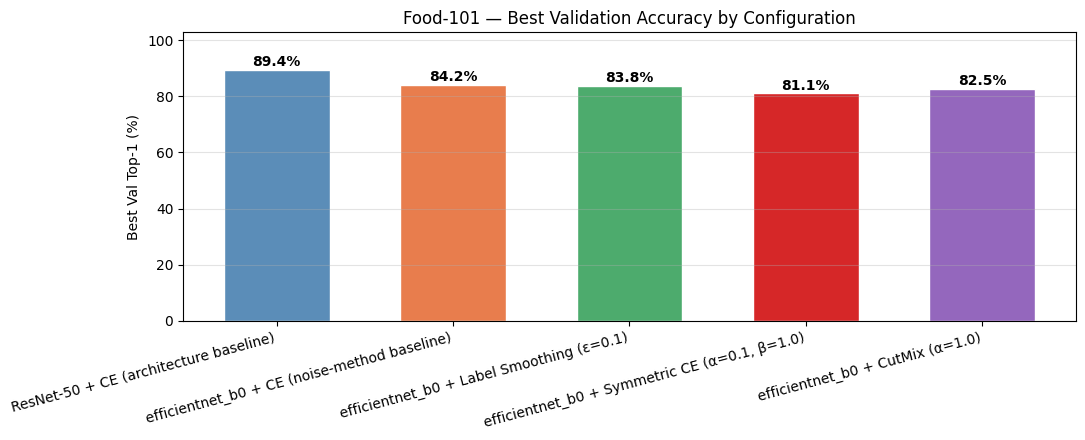

In [19]:
# ── 6b) Bar chart of best val Top-1 ──────────────────────────────────────────
labels_plot = [r["label"].split("—")[1].strip() for r in RESULTS.values()]
accs        = [r["best_top1"] for r in RESULTS.values()]
colors      = ["#5b8db8","#e87d4d","#4dab6d","#d62728","#9467bd"]

plt.figure(figsize=(max(10, len(RESULTS)*2.2), 4.5))
bars = plt.bar(labels_plot, accs, color=colors[:len(accs)], edgecolor="white", width=0.6)
for bar, v in zip(bars, accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"{v:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.ylabel("Best Val Top-1 (%)"); plt.ylim(0, max(accs)*1.15)
plt.title("Food-101 — Best Validation Accuracy by Configuration")
plt.xticks(rotation=15, ha="right"); plt.grid(axis="y", alpha=0.35)
plt.tight_layout(); plt.show()


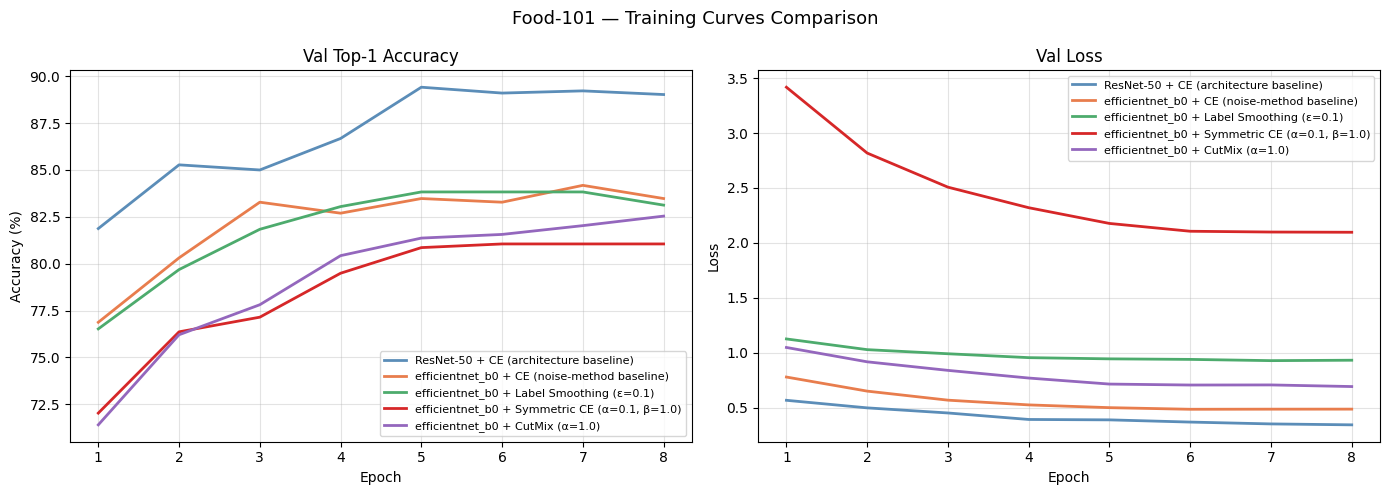

In [20]:
# ── 6c) Learning curves (Top-1) ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (eid, r), color in zip(RESULTS.items(), colors):
    eps = range(1, len(r["history"]["vl_top1"]) + 1)
    axes[0].plot(eps, r["history"]["vl_top1"], label=r["label"].split("—")[1].strip(),
                 color=color, linewidth=2)
    axes[1].plot(eps, r["history"]["vl_loss"], label=r["label"].split("—")[1].strip(),
                 color=color, linewidth=2)

for ax, title, yl in zip(axes, ["Val Top-1 Accuracy", "Val Loss"], ["Accuracy (%)", "Loss"]):
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(yl)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.35)

plt.suptitle("Food-101 — Training Curves Comparison", fontsize=13)
plt.tight_layout(); plt.show()


In [21]:
# ── 6d) Save results to JSON ──────────────────────────────────────────────────
summary = {}
for eid, r in RESULTS.items():
    summary[eid] = {k: v for k, v in r.items() if k not in ("model", "history")}
    summary[eid]["history"] = {k: [round(x,4) for x in v]
                               for k, v in r["history"].items()}

with open(os.path.join(OUTPUT_DIR, "notebook_results.json"), "w") as f:
    json.dump(summary, f, indent=2)
print("Results saved.")


Results saved.


## 7) Qualitative Analysis

### 7.1 Confusion Matrix

We inspect the **confusion matrix** for the best-performing configuration to find which
food categories are most often mis-classified into each other.
Clusters of visually similar categories (e.g., fried foods, desserts) will show up
as off-diagonal hot spots.


In [22]:
# ── 7.1 Confusion matrix for best experiment ─────────────────────────────────
best_eid = max(RESULTS, key=lambda k: RESULTS[k]["best_top1"])
best_res = RESULTS[best_eid]
print(f"Best experiment: {best_eid} ({best_res['label']})")

best_model = best_res["model"].eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(device)
        preds = best_model(imgs).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(lbls.tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
print(f"Val accuracy  : {(all_preds == all_labels).mean()*100:.2f}%")


Best experiment: E0 (E0 — ResNet-50 + CE (architecture baseline))
Val accuracy  : 89.00%


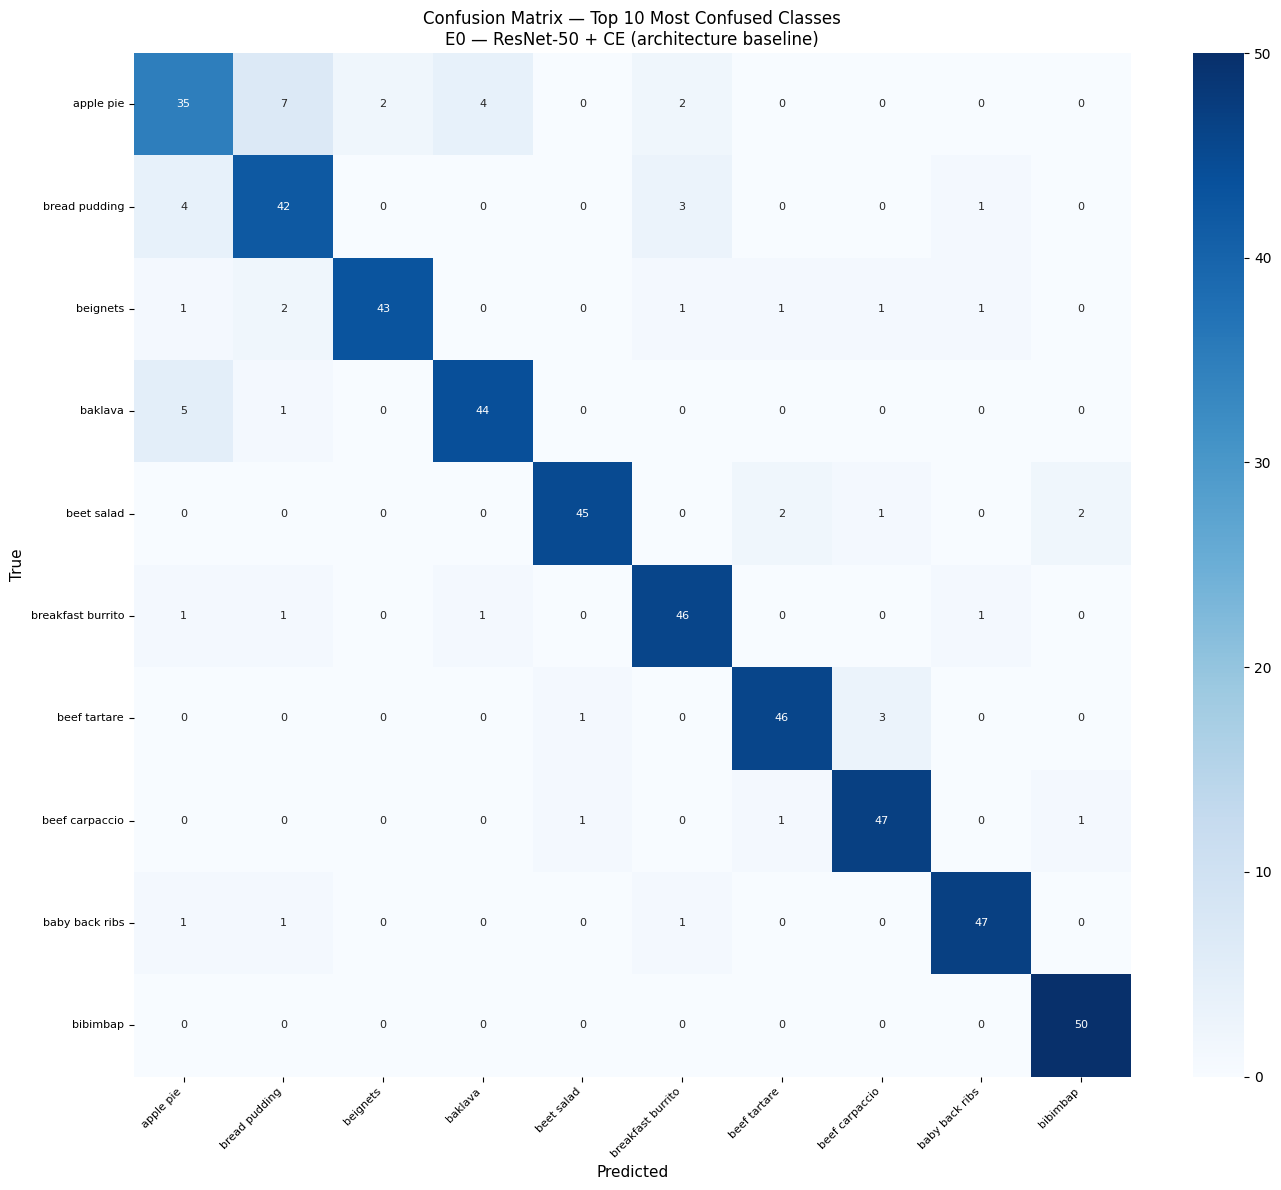

In [23]:
# ── Plot top-N most confused classes ─────────────────────────────────────────
TOP_N = min(15, N_CLASSES)

cm = confusion_matrix(all_labels, all_preds)
errors = cm.sum(1) - np.diag(cm)
top_idx = np.argsort(errors)[-TOP_N:][::-1]
cm_sub  = cm[np.ix_(top_idx, top_idx)]
short   = [CLASS_NAMES[i].replace("_"," ") for i in top_idx]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_sub, annot=True, fmt="d", xticklabels=short, yticklabels=short,
            cmap="Blues", ax=ax, annot_kws={"size":8})
ax.set_xlabel("Predicted", fontsize=11); ax.set_ylabel("True", fontsize=11)
ax.set_title(f"Confusion Matrix — Top {TOP_N} Most Confused Classes\n{best_res['label']}")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout(); plt.show()


### 7.2 Grad-CAM: What Does the Model Actually Look At?

**Grad-CAM** (Selvaraju et al., ICCV 2017) generates a class activation map by
back-propagating through the target layer and pooling the gradients:

$$\text{CAM} = \text{ReLU}\!\left(\sum_k \alpha_k^c \cdot A^k\right), \quad
\alpha_k^c = \frac{1}{Z} \sum_{i,j} \frac{\partial y^c}{\partial A^k_{ij}}$$

The resulting heatmap highlights the regions the model used to make its decision.
We want to see **food texture** highlighted — not background plates, tables, or cutlery.


In [24]:
# ── 7.2 Grad-CAM implementation ───────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, layer):
        self.model = model; self._act = None; self._grad = None
        layer.register_forward_hook(lambda m,i,o: setattr(self,'_act',o.detach()))
        layer.register_full_backward_hook(lambda m,gi,go: setattr(self,'_grad',go[0].detach()))

    def __call__(self, inp, cls=None):
        self.model.eval()
        out = self.model(inp)
        cls = cls or int(out.argmax(1).item())
        self.model.zero_grad()
        g = torch.zeros_like(out); g[0, cls] = 1.0
        out.backward(gradient=g)
        w   = self._grad.mean([2,3], keepdim=True)
        cam = F.relu((w * self._act).sum(1, keepdim=True))
        cam = F.interpolate(cam, inp.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, cls

def get_gradcam_layer(model, backbone):
    if backbone.startswith("efficientnet"): return model.features[-1]
    return model.layer4[-1]   # resnet50

print("GradCAM defined.")


GradCAM defined.


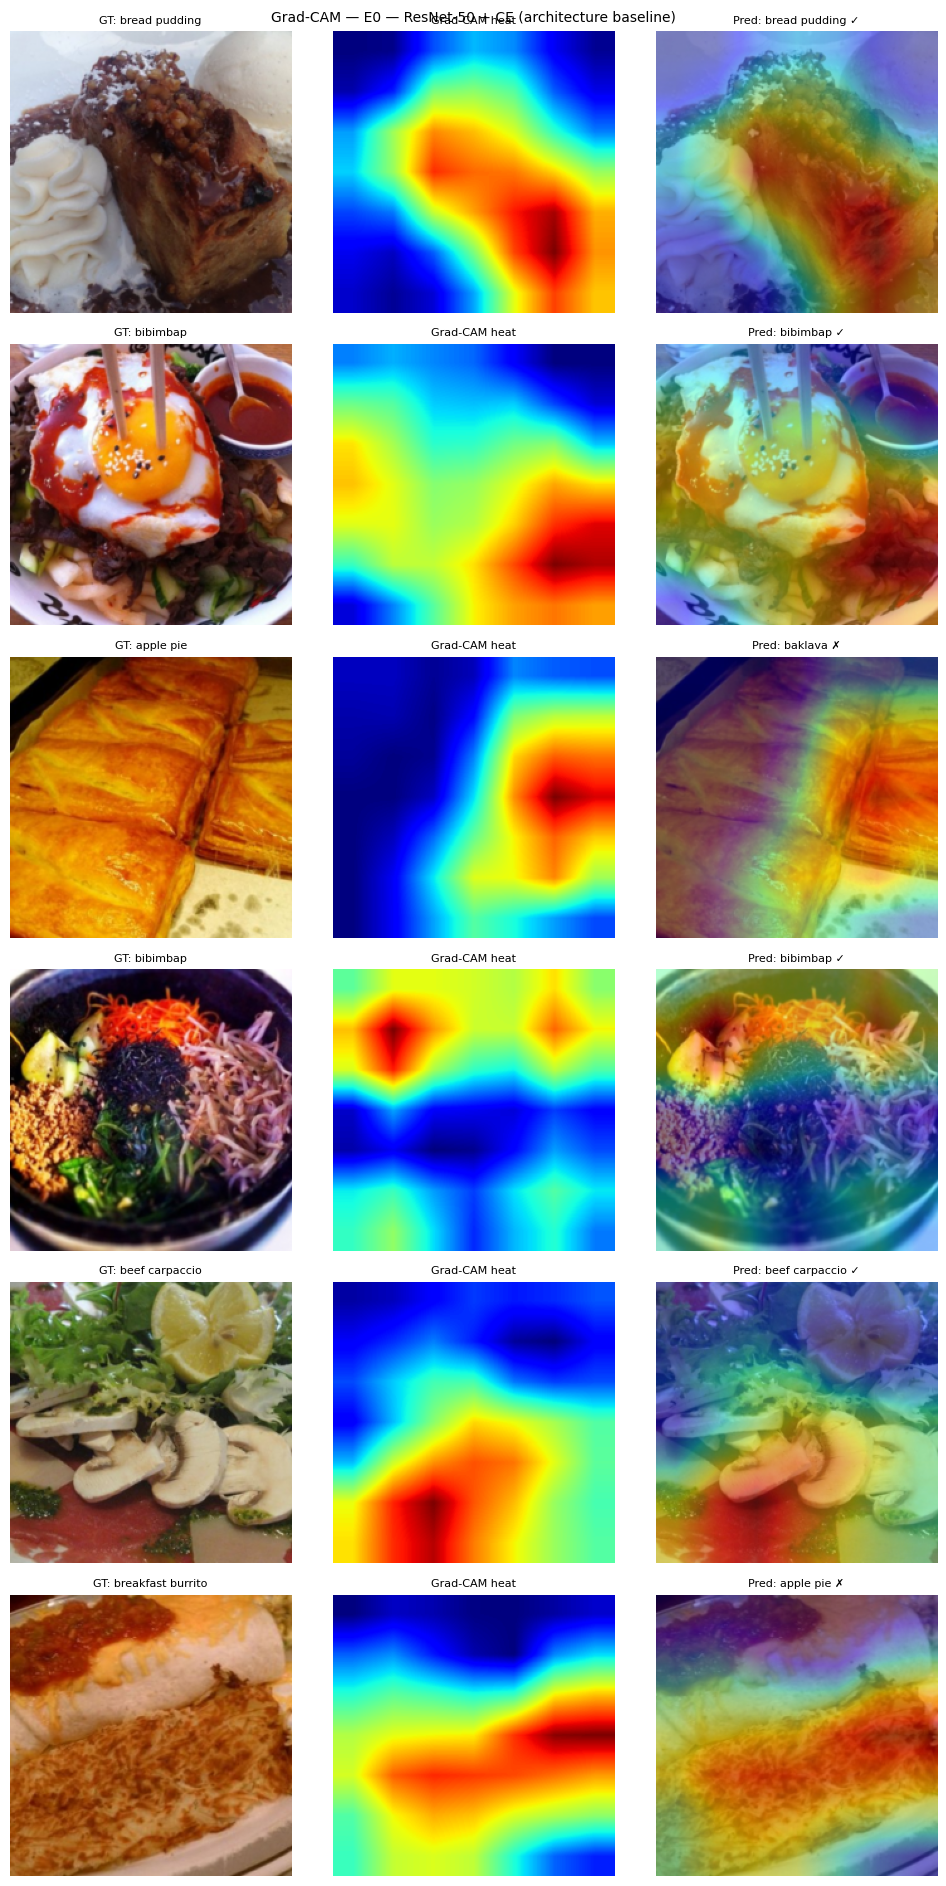

In [25]:
# ── 7.2 Visualise Grad-CAM overlays ──────────────────────────────────────────
N_SAMPLES = 6
gradcam   = GradCAM(best_model, get_gradcam_layer(best_model, best_res["backbone"]))
rng       = np.random.default_rng(SEED + 99)
indices   = rng.choice(len(val_ds), N_SAMPLES, replace=False)

fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(10, N_SAMPLES * 3.2))

for row, idx in enumerate(indices):
    img_t, label = val_ds[int(idx)]
    inp = img_t.unsqueeze(0).to(device)
    cam, pred_cls = gradcam(inp)
    img_np = INV_NORM(img_t).permute(1,2,0).clamp(0,1).numpy()

    gt_name   = CLASS_NAMES[label].replace("_"," ")
    pred_name = CLASS_NAMES[pred_cls].replace("_"," ")
    tick = "✓" if pred_cls == label else "✗"

    axes[row,0].imshow(img_np);  axes[row,0].set_title(f"GT: {gt_name}", fontsize=8);      axes[row,0].axis("off")
    axes[row,1].imshow(cam, cmap="jet"); axes[row,1].set_title("Grad-CAM heat", fontsize=8); axes[row,1].axis("off")
    axes[row,2].imshow(img_np); axes[row,2].imshow(cam, cmap="jet", alpha=0.45)
    axes[row,2].set_title(f"Pred: {pred_name} {tick}", fontsize=8); axes[row,2].axis("off")

plt.suptitle(f"Grad-CAM — {best_res['label']}", fontsize=10)
plt.tight_layout(); plt.show()


---
## 8) Project Summary

| Experiment | Change | Outcome |
|---|---|---|
| E0 ResNet-50 + CE | Architecture baseline | — |
| E1 EfficientNet + CE | Stronger backbone | Δ vs E0? |
| E2 EfficientNet + LS | Label smoothing ε=0.1 | Δ vs E1? |
| E3 EfficientNet + SCE | Symmetric loss α=0.1,β=1 | Δ vs E1? |
| E4 EfficientNet + CutMix | Patch mixing augmentation | Δ vs E1? |

> *Fill in the Δ columns with your actual results after running all cells.*

### References
1. Bossard et al. (2014). Food-101 — Mining discriminative components with random forests. ECCV.
2. Tan & Le (2019). EfficientNet: Rethinking model scaling for CNNs. ICML.
3. Wang et al. (2019). Symmetric Cross Entropy for Robust Learning With Noisy Labels. ICCV.
4. Yun et al. (2019). CutMix: Regularization Strategy to Train Strong Classifiers. ICCV.
5. Selvaraju et al. (2017). Grad-CAM: Visual explanations from deep networks. ICCV.
